In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [7]:
blob_centers = np.array([[0.2, 2.3],[-1.5, 2.3],[-2.8, 1.8],[-2.8, 2.8],[-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=101)

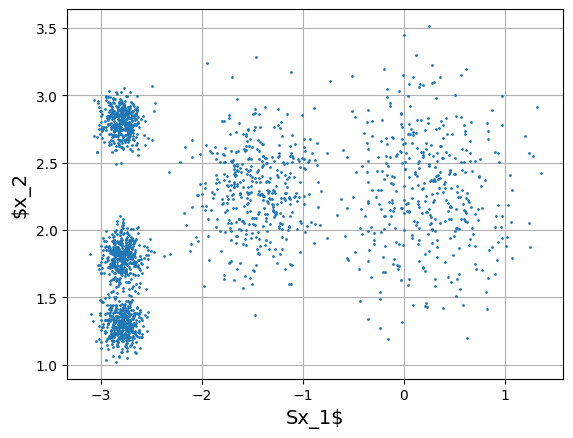

In [8]:
def plt_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel('Sx_1$')
    plt.ylabel('$x_2')

plt_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

In [9]:
n_clusters = 5
max_iters = 1000

rng = np.random.default_rng(seed=42)
centroids = X[rng.choice(len(X), n_clusters, replace=False)]

for _ in range(max_iters):
    distances = np.linalg.norm(X[:, None] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(n_clusters)])

    converged = np.allclose(centroids, new_centroids)
    centroids = new_centroids

    if converged:
        break

centroids

array([[-1.44302069,  2.29563944],
       [-2.79515956,  1.30093499],
       [-2.77950906,  1.8077965 ],
       [ 0.23833329,  2.29103643],
       [-2.79246994,  2.79993707]])

In [10]:
from sklearn.base import BaseEstimator

In [11]:
class MyKMeans(BaseEstimator):
    def __init__(self, n_clusters=3, max_iter=100, random_state=None):
        self.n_clusters_ = n_clusters
        self.max_iter_ = max_iter
        self.random_state_ = random_state

    def fit(self, X, y=None):
        rng = np.random.default_rng(seed=self.random_state_)
        self.cluster_centers_ = X[rng.choice(len(X), self.n_clusters_, replace=False)]
        
        for _ in range(self.max_iter_):
            distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
            labels = np.argmin(distances, axis=1)
        
            new_centroids = np.array(
                [X[labels == k].mean(axis=0)
                 for k in range(self.n_clusters_)])
        
            converged = np.allclose(self.cluster_centers_, new_centroids)
            self.cluster_centers_ = new_centroids
        
            if converged:
                break
        distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
        self.labels_ = np.argmin(distances, axis=1)
        self.inertia_ = np.sum((X-self.cluster_centers_[self.labels_]))
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1)

In [13]:
#código proporcionado por prof. Edson
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
 
def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)
 
def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
 
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap='Set2')
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
 
    if show_xlabels:
        plt.xlabel('$x_1$')
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel('$x_2$')#, rotation=0)
    else:
        plt.tick_params(labelleft=False)

Inertia: 1.021405182655144e-13


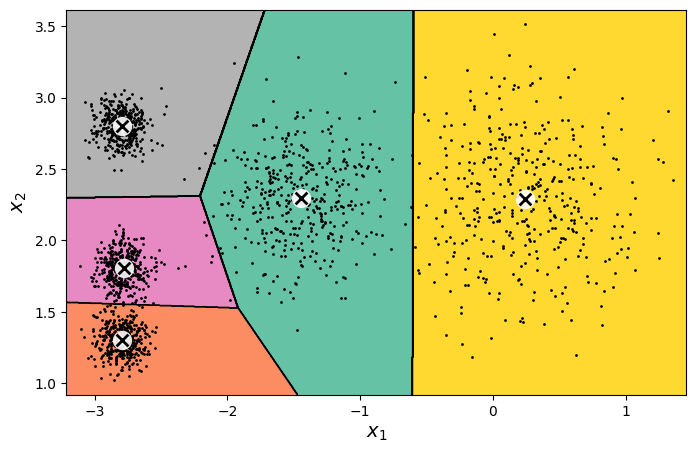

In [14]:
model = MyKMeans(n_clusters=5, max_iter=100, random_state=42)
model.fit(X)

print(f'Inertia: {model.inertia_}')

plt.figure(figsize=(8,5))
plot_decision_boundaries(model,X)
plt.show()

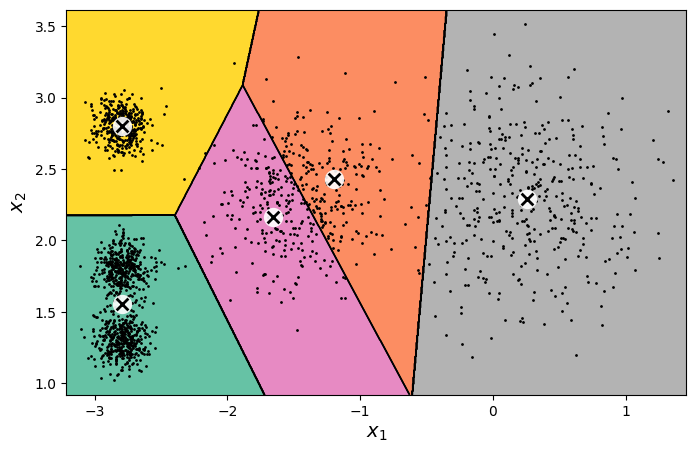

In [16]:
model = MyKMeans(n_clusters=5, max_iter=100, random_state=101)
model.fit(X)

plt.figure(figsize=(8,5))
plot_decision_boundaries(model, X)
plt.show()

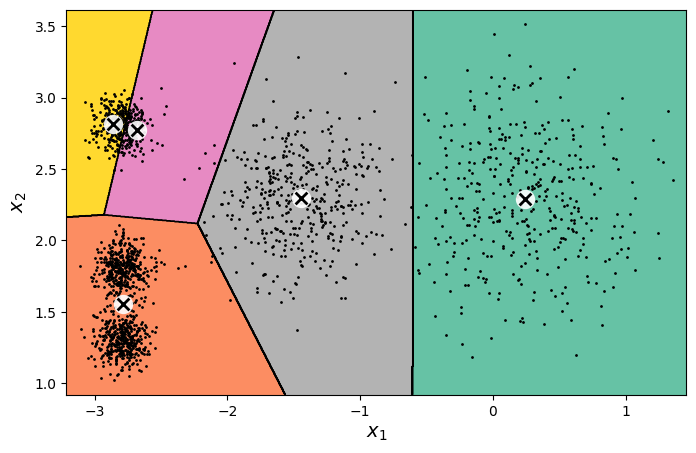

In [17]:
model = MyKMeans(n_clusters=5, max_iter=100, random_state=250)
model.fit(X)

plt.figure(figsize=(8,5))
plot_decision_boundaries(model, X)
plt.show()

In [18]:
from sklearn.cluster import k_means

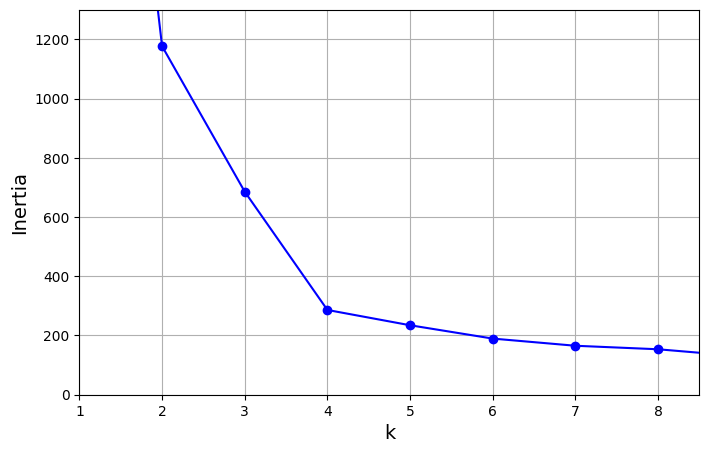

In [19]:
kmeans_per_k = [KMeans(n_clusters=k, init='random', n_init=10, random_state=42).fit(X) for k in range(1,10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.axis([1,8.5,0,1300])
plt.grid()
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

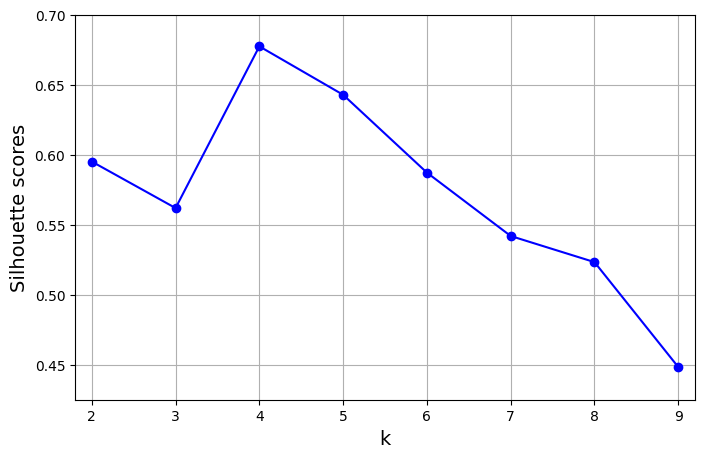

In [27]:
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8,5))
plt.plot(range(2,10), silhouette_scores, 'bo-')
plt.xlabel('k')
plt.ylabel('Silhouette scores')
plt.axis([1.8,9.2,0.425,0.7])
plt.grid()
plt.show()

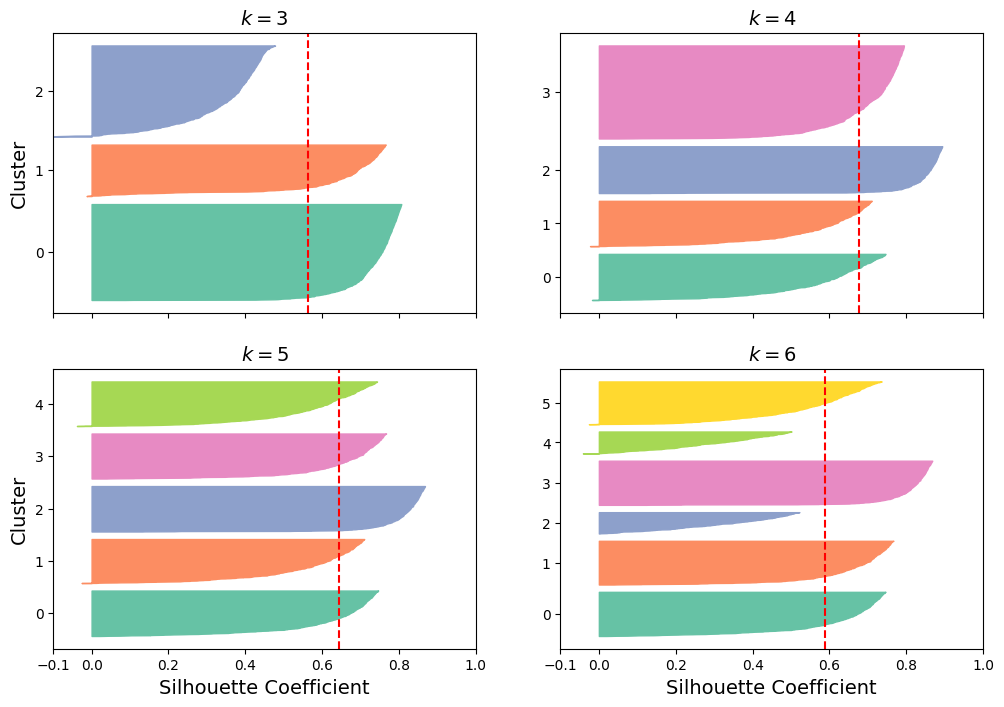

In [30]:
#Diagrama de siluetas
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

 

plt.figure(figsize=(12, 8))

 

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

 

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

 

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

 

        color = plt.cm.Set2(i / 8) # changed to reuse colors in all subplots
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=1)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

 

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel('Cluster')

 

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlim([-0.1, 1])
    if k in (5, 6):
        plt.xlabel('Silhouette Coefficient')
    else:
        plt.tick_params(labelbottom=False)

 

    plt.axvline(x=silhouette_scores[k - 2], color='red', linestyle='--')
    plt.title(f'$k={k}$')

 

plt.show()